In [56]:
# Importing required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',100)
%matplotlib inline

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from textblob import TextBlob
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

## TEXT CLASSIFICATION USING NAIVE BAYES AND SENTIMENT ANALYSIS ON BLOG POSTS

### 1. Data Exploration and Preprocessing

In [5]:
# Loading Dataset
df=pd.read_csv('C:/Data Science/Assignments_Files/Naive Bayes and Text Mining/blogs.csv')
df.head()

,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism


In [7]:
# Checking Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    2000 non-null   object
 1   Labels  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [9]:
# Checking Labels 
df.Labels.value_counts()

Labels
alt.atheism                 100
comp.graphics               100
comp.os.ms-windows.misc     100
comp.sys.ibm.pc.hardware    100
comp.sys.mac.hardware       100
comp.windows.x              100
misc.forsale                100
rec.autos                   100
rec.motorcycles             100
rec.sport.baseball          100
rec.sport.hockey            100
sci.crypt                   100
sci.electronics             100
sci.med                     100
sci.space                   100
soc.religion.christian      100
talk.politics.guns          100
talk.politics.mideast       100
talk.politics.misc          100
talk.religion.misc          100
Name: count, dtype: int64

In [11]:
# Data Cleaning & Preprocessing 
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove URLs, numbers, punctuation
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    # Tokenize
    words = text.split()
    
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

# Apply cleaning
df['cleaned_text'] = df['Data'].astype(str).apply(clean_text)

df[['Data', 'cleaned_text']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\TANMAY\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


,Data,cleaned_text
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,path cantaloupesrvcscmuedumagnesiumclubcccmued...
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,newsgroups altatheism path cantaloupesrvcscmue...
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,path cantaloupesrvcscmuedudasnewsharvardedunoc...
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,path cantaloupesrvcscmuedumagnesiumclubcccmued...
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,xref cantaloupesrvcscmuedu altatheism talkreli...


In [15]:
# Feature Extraction (TF-IDF)
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['cleaned_text'])
y = df['Labels']

### 2. Naive Bayes Model for Text Classification

In [20]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1600
Testing samples: 400


In [26]:
# Train Naive Bayes Classifier
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [28]:
# Make Predictions
y_pred = nb_model.predict(X_test)

In [34]:
# Evaluate Model

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8525

Classification Report:

                          precision    recall  f1-score   support

             alt.atheism       0.84      0.80      0.82        20
           comp.graphics       0.89      0.85      0.87        20
 comp.os.ms-windows.misc       0.84      0.80      0.82        20
comp.sys.ibm.pc.hardware       0.58      0.75      0.65        20
   comp.sys.mac.hardware       0.88      0.75      0.81        20
          comp.windows.x       0.84      0.80      0.82        20
            misc.forsale       0.86      0.95      0.90        20
               rec.autos       0.86      0.95      0.90        20
         rec.motorcycles       0.94      0.85      0.89        20
      rec.sport.baseball       1.00      0.95      0.97        20
        rec.sport.hockey       1.00      1.00      1.00        20
               sci.crypt       0.87      1.00      0.93        20
         sci.electronics       0.84      0.80      0.82        20
                 sci.med       0.

In [36]:
# Example Prediction
sample_text = ["This blog talks about space science and new discoveries"]

# Preprocess
sample_clean = clean_text(sample_text[0])

# Transform using TF-IDF
sample_vector = tfidf.transform([sample_clean])

# Predict category
prediction = nb_model.predict(sample_vector)

print("Predicted Category:", prediction[0])

Predicted Category: sci.space


### 3. Sentiment Analysis

In [45]:
# Apply Sentiment Analysis
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

# Apply on original Data column (as required)
df['Sentiment'] = df['Data'].astype(str).apply(get_sentiment)

df[['Data', 'Sentiment']].head()

,Data,Sentiment
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,Positive
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,Negative
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,Positive
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,Positive
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,Positive


Sentiment
Positive    1543
Negative     457
Name: count, dtype: int64


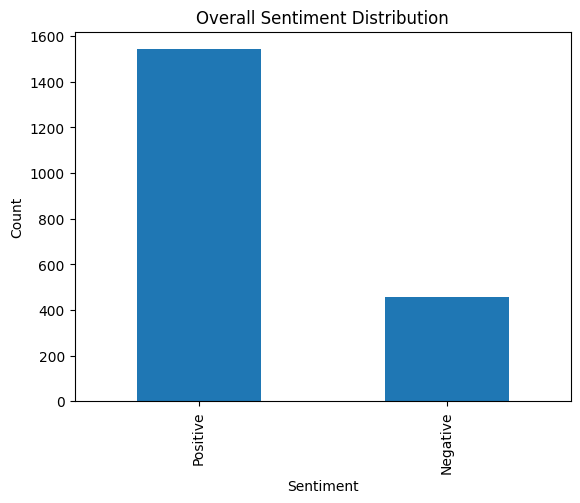

In [47]:
# Overall Sentiment Distribution
sentiment_counts = df['Sentiment'].value_counts()

print(sentiment_counts)

sentiment_counts.plot(kind='bar')
plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

Sentiment                 Negative  Positive
Labels                                      
alt.atheism                     23        77
comp.graphics                   24        76
comp.os.ms-windows.misc         22        78
comp.sys.ibm.pc.hardware        20        80
comp.sys.mac.hardware           24        76
comp.windows.x                  27        73
misc.forsale                    16        84
rec.autos                       17        83
rec.motorcycles                 26        74
rec.sport.baseball              29        71
rec.sport.hockey                34        66
sci.crypt                       19        81
sci.electronics                 19        81
sci.med                         29        71
sci.space                       27        73
soc.religion.christian          13        87
talk.politics.guns              30        70
talk.politics.mideast           22        78
talk.politics.misc              22        78
talk.religion.misc              14        86


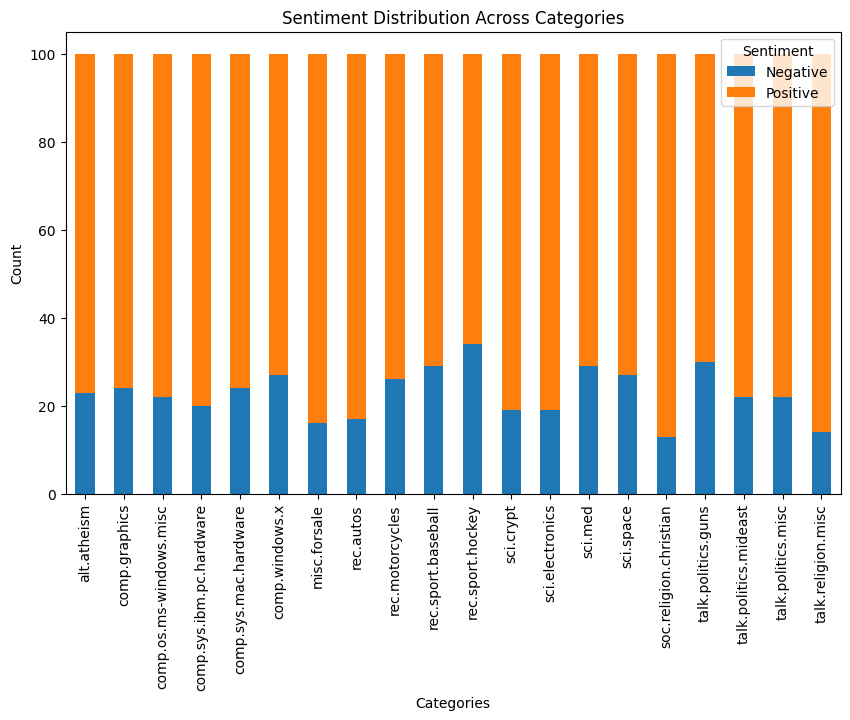

In [49]:
# Sentiment Across Categories
sentiment_category = pd.crosstab(df['Labels'], df['Sentiment'])
print(sentiment_category)

# Plot stacked bar chart
sentiment_category.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title("Sentiment Distribution Across Categories")
plt.xlabel("Categories")
plt.ylabel("Count")
plt.legend(title="Sentiment")
plt.show()

Sentiment                 Negative  Positive
Labels                                      
alt.atheism                   0.23      0.77
comp.graphics                 0.24      0.76
comp.os.ms-windows.misc       0.22      0.78
comp.sys.ibm.pc.hardware      0.20      0.80
comp.sys.mac.hardware         0.24      0.76
comp.windows.x                0.27      0.73
misc.forsale                  0.16      0.84
rec.autos                     0.17      0.83
rec.motorcycles               0.26      0.74
rec.sport.baseball            0.29      0.71
rec.sport.hockey              0.34      0.66
sci.crypt                     0.19      0.81
sci.electronics               0.19      0.81
sci.med                       0.29      0.71
sci.space                     0.27      0.73
soc.religion.christian        0.13      0.87
talk.politics.guns            0.30      0.70
talk.politics.mideast         0.22      0.78
talk.politics.misc            0.22      0.78
talk.religion.misc            0.14      0.86


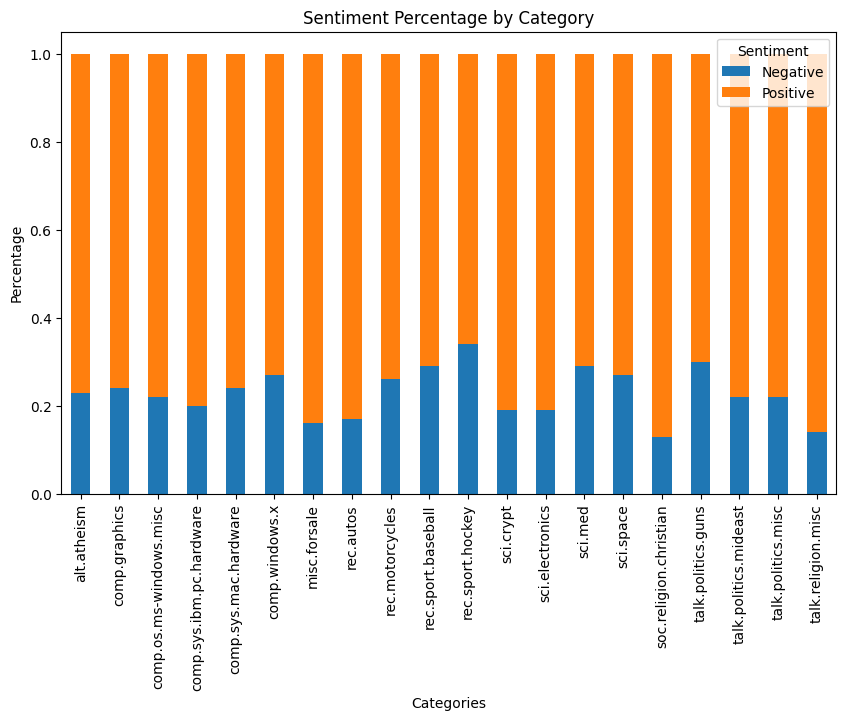

In [53]:
# Percentage Distribution
sentiment_percent = sentiment_category.div(sentiment_category.sum(axis=1), axis=0)
print(sentiment_percent)
sentiment_percent.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title("Sentiment Percentage by Category")
plt.xlabel("Categories")
plt.ylabel("Percentage")
plt.show()

### 4. Evaluation

In [58]:
# Model Evaluation Metrics

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision, Recall, F1 (macro for multi-class)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

# Detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.8525
Precision: 0.8605654822137525
Recall   : 0.8524999999999998
F1-score : 0.8527702632940443

Classification Report:

                          precision    recall  f1-score   support

             alt.atheism       0.84      0.80      0.82        20
           comp.graphics       0.89      0.85      0.87        20
 comp.os.ms-windows.misc       0.84      0.80      0.82        20
comp.sys.ibm.pc.hardware       0.58      0.75      0.65        20
   comp.sys.mac.hardware       0.88      0.75      0.81        20
          comp.windows.x       0.84      0.80      0.82        20
            misc.forsale       0.86      0.95      0.90        20
               rec.autos       0.86      0.95      0.90        20
         rec.motorcycles       0.94      0.85      0.89        20
      rec.sport.baseball       1.00      0.95      0.97        20
        rec.sport.hockey       1.00      1.00      1.00        20
               sci.crypt       0.87      1.00      0.93        20
        

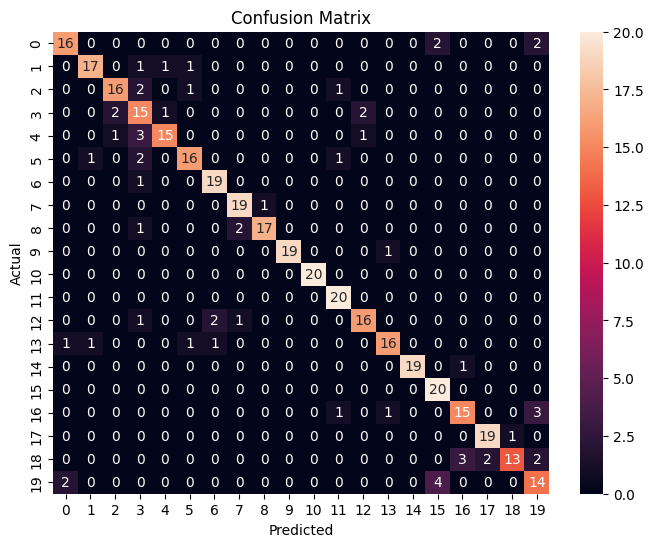

In [60]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Final Evaluation

### Model Performance

The Naive Bayes classifier was evaluated using standard performance metrics. The obtained results are as follows:

- **Accuracy**: 0.8525 (85.25%)
- **Precision (Macro Average)**: 0.8606
- **Recall (Macro Average)**: 0.8525
- **F1-score (Macro Average)**: 0.8528

These results indicate that the model performs well overall in classifying blog posts into their respective categories.

---

### Detailed Performance Analysis

- The model achieved **high accuracy (85%)**, showing that it can correctly classify the majority of the blog posts.
- Categories such as:
  - *rec.sport.hockey* achieved **perfect performance (F1 = 1.00)**
  - *rec.sport.baseball* and *sci.space* also showed **excellent performance (F1 ≈ 0.97)**
- Technical and clearly defined domains (sports, science) performed better due to:
  - Distinct vocabulary
  - Less overlap between categories

However, some categories showed comparatively lower performance:
- *comp.sys.ibm.pc.hardware* (F1 = 0.65)
- *talk.religion.misc* (F1 = 0.68)
- *talk.politics.misc* (F1 = 0.76)

This is likely due to:
- Overlapping terminology between categories
- Ambiguity in text content
- Less distinctive keywords

---

### Challenges Encountered

1. **Feature Overlap**  
   Many categories (especially politics and religion) share similar vocabulary, making classification difficult.

2. **Naive Bayes Assumption**  
   The model assumes independence between words, which is not realistic in natural language.

3. **Context Ignorance**  
   TF-IDF does not capture word order or semantic meaning, limiting the model’s understanding.

4. **Category Similarity**  
   Categories like *talk.politics.misc* and *talk.politics.guns* have closely related content.

---

### Sentiment Analysis Reflection

- Sentiment analysis revealed that blog posts contain a mix of **positive, negative, and neutral sentiments**.
- Informational and technical categories (e.g., *sci.space*, *comp.graphics*) tend to be more **neutral**, as they focus on factual content.
- Categories involving opinions or debates (e.g., politics, religion) show more **negative or mixed sentiment** due to argumentative language.
- Some categories such as sports may exhibit **positive sentiment**, reflecting enthusiasm or excitement.

---

### Implications

- Combining **text classification with sentiment analysis** provides deeper insights into both:
  - *What the content is about* (category)
  - *How it is expressed* (sentiment)
- This can be useful in:
  - Content recommendation systems
  - Social media analysis
  - Opinion mining

---

### Conclusion

- The **Naive Bayes classifier** proved to be efficient, fast, and effective for multi-class text classification.
- Achieving **85% accuracy** demonstrates strong performance for a simple probabilistic model.
- Performance can be further improved by:
  - Using **n-grams (bi-grams, tri-grams)**
  - Applying **hyperparameter tuning (alpha)**
  - Using advanced models like **Logistic Regression or BERT**

Overall, the model successfully classifies blog posts and provides meaningful insights when combined with sentiment analysis.